# NEURAL NETWORK FROM SCRATCH

# Phase 1:

## IMPORT LIBRARIES AND LOAD DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [35]:
data = pd.read_csv('/Users/nguyen3503/Documents/ML/DL/digit-recognizer/train.csv')

In [36]:
data 


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## DATA PREPARATION

In [37]:

data = np.array(data)
m, n  = data.shape
data_dev = data[:1000]
data_train = data[1000:m]

X_train= data_train[:,1:n].T
y_train = data_train[:, 0]
X_dev = data_dev[:,1:n].T
y_dev = data_dev[:,0]

In [38]:
# Normalize the Data
X_train = 1/255 * X_train # (784, 41000)
X_dev = 1/255 * X_dev
y_train # (10, 1000)

array([1, 5, 1, ..., 7, 6, 9])

In [39]:
# One - hot encoding labes function for y:
def one_hot_enc(Y):
    one_hot = np.zeros((Y.size, Y.max() + 1))
    one_hot[np.arange(Y.size), Y] = 1
    one_hot= one_hot.T
    return one_hot.astype(int)

# Phase 2:

## PARAMETER INITIALIZATION

In [40]:
# Network Dimensions
input_size = 784
hidden_size = 10
output_size = 10

# Initialzize Weights and Biases:
W1 = np.random.randn(hidden_size, input_size) * 0.01
b1 = np.zeros((hidden_size, 1))
W2 = np.random.randn(output_size, hidden_size) * 0.01
b2 = np.zeros((output_size, 1))

    

In [41]:
# Checkpoints: Shape of all initialized parameters
'''
print(W1.shape, W2.shape)
print(b1.shape, b2.shape)
'''


'\nprint(W1.shape, W2.shape)\nprint(b1.shape, b2.shape)\n'

## Phase 3:

## IMPLEMENT FORWARD PROPAGATION

In [42]:
# RELU ACTIVATION FUNCTION 
def ReLU(Z):
    return np.maximum(0, Z)

# Softmax ACTIVATION FUNCTION
def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [43]:
# Forward Propagation Function:
def forward_propagation(X, W1, b1, W2, b2):
    z1 = W1 @ X + b1
    a1 = ReLU(z1)
    z2 = W2 @ a1 + b2
    a2 = softmax(z2)
    return a1, a2, z1, z2

In [44]:
# Checkpoint:
Z = [-1,2,3,-5,5,6]
Z = np.array(Z)
print(ReLU(Z))
print(softmax(Z))


[0 2 3 0 5 6]
[6.34612816e-04 1.27465391e-02 3.46486857e-02 1.16233392e-05
 2.56021083e-01 6.95937456e-01]


## PHASE 4: IMPLEMENT BACKPROPAGATION

In [45]:
# ReLU Derivative
def dReLU(Z):
    return (Z > 0) * 1

# Cross - Entropy Loss
def cross_ent_loss(m, Y, A2):
    eps = 1e-12
    A2 = np.clip(A2, eps, 1 - eps)   # avoid log(0)
    return -np.sum(Y * np.log(A2)) / m

In [61]:
# Backpropagation Algorithms
def back_propagation(W1, b1, W2, b2, A1, A2, X, Y, z1, m):
    # 1.Compute output of layer gradient:
    dz2 = A2 - Y
    dW2 = 1/m * dz2 @ A1.T
    db2 = 1/m * np.sum(dz2, axis = 1, keepdims = True)
    
    # 2. Compute hidden layer gradient:
    dA1 = W2.T @ dz2
    dz1 = dA1 * dReLU(z1)
    dW1 = 1/m * dz1 @ X.T
    db1 = 1/m * np.sum(dz1, axis = 1, keepdims = True)

    return dW1, db1, dW2, db2

# a1, a2, z1, z2 = forward_propagation(X_train, W1, b1, W2, b2)
# y_train = one_hot_enc(y_train)
# dW1, db1, dW2, db2 = back_propagation(W1, b1, W2, b2, a1, a2, X_train, y_train, z1, m)




In [62]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)


def get_accuracy(preds, y_true):
    return np.mean(preds == y_true)


def evaluate(X, y, W1, b1, W2, b2):
    _, A2, _, _ = forward_propagation(X, W1, b1, W2, b2)
    preds = get_predictions(A2)
    acc = get_accuracy(preds, y)
    return preds, acc

In [63]:
''' 
# Check point of Backpropagation process
print(bool (dW1.shape == W1.shape))
print(bool (db1.shape == b1.shape))
print(bool (dW2.shape == W2.shape))
print(bool (db2.shape == b2.shape))
'''

' \n# Check point of Backpropagation process\nprint(bool (dW1.shape == W1.shape))\nprint(bool (db1.shape == b1.shape))\nprint(bool (dW2.shape == W2.shape))\nprint(bool (db2.shape == b2.shape))\n'

## PHASE 5: PARAMETER UPDATE

In [64]:
# Update Process:
def update_func(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [65]:
def train_func(W1, b1, W2, b2, X_train, Y_train_oh, Y_train_raw, X_dev, y_dev, alpha, iters, m):
    losses = []
    train_accs = []
    dev_accs = []

    for i in range(iters):
        a1, a2, z1, z2 = forward_propagation(X_train, W1, b1, W2, b2)
        loss = cross_ent_loss(m, Y_train_oh, a2)
        dW1, db1, dW2, db2 = back_propagation(W1, b1, W2, b2, a1, a2, X_train, Y_train_oh, z1, m)
        W1, b1, W2, b2 = update_func(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        train_preds, train_acc = evaluate(X_train, Y_train_raw, W1, b1, W2, b2)
        dev_preds, dev_acc = evaluate(X_dev, y_dev, W1, b1, W2, b2)

        losses.append(loss)
        train_accs.append(train_acc)
        dev_accs.append(dev_acc)

        if i % 50 == 0:
            print(f'Iteration {i}, Loss: {loss}, Train Acc: {train_acc}, Dev Acc: {dev_acc}')

        if np.isnan(loss) or np.isinf(loss):
            print("Numerical issue detected. Stop training.")
            break

    return W1, b1, W2, b2, losses, train_accs, dev_accs

In [66]:
y_train_raw = data_train[:, 0]
y_train_oh = one_hot_enc(y_train_raw).astype(float)
m = X_train.shape[1]

W1, b1, W2, b2, losses, train_accs, dev_accs = train_func(
    W1, b1, W2, b2,
    X_train, y_train_oh, y_train_raw,
    X_dev, y_dev,
    alpha=0.01,
    iters=2000,
    m=m,
)

Iteration 0, Loss: 0.7340313043748059, Train Acc: 0.7878536585365854, Dev Acc: 0.808
Iteration 50, Loss: 0.7171632011943557, Train Acc: 0.7927804878048781, Dev Acc: 0.811
Iteration 100, Loss: 0.7012015552317357, Train Acc: 0.7978780487804878, Dev Acc: 0.815
Iteration 150, Loss: 0.686079628883185, Train Acc: 0.8025609756097561, Dev Acc: 0.822
Iteration 200, Loss: 0.6717364566726718, Train Acc: 0.8076585365853659, Dev Acc: 0.825
Iteration 250, Loss: 0.6581191067064547, Train Acc: 0.811439024390244, Dev Acc: 0.83
Iteration 300, Loss: 0.6451805893566313, Train Acc: 0.8155365853658536, Dev Acc: 0.832
Iteration 350, Loss: 0.6328749286462498, Train Acc: 0.819, Dev Acc: 0.833
Iteration 400, Loss: 0.6211636897241983, Train Acc: 0.822780487804878, Dev Acc: 0.831
Iteration 450, Loss: 0.6100096955366912, Train Acc: 0.8259756097560975, Dev Acc: 0.835
Iteration 500, Loss: 0.5993778269785102, Train Acc: 0.8300731707317073, Dev Acc: 0.839
Iteration 550, Loss: 0.5892355344434631, Train Acc: 0.833390243

## PHASE 7: EVALUATION

In [78]:
data_test = pd.read_csv('/Users/nguyen3503/Documents/ML/DL/digit-recognizer/mnist_test.csv')

In [79]:
data_test

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
data_test = np.array(data_test)
j,k = data_test.shape

In [81]:
print(j,k)

10000 785


In [82]:
X_test = data_test[:,1:k].T
y_test = data_test[:,0]
X_test = 1/255 * X_test

In [83]:
a1_t, a2_t, z1_t, z2_t = forward_propagation(X_test, W1, b1, W2, b2)


In [88]:
output_labels = np.argmax(a2_t, axis = 0)
print(output_labels[:20])

[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


In [85]:
accuracy = np.mean(output_labels == y_test) * 100

In [86]:
accuracy

np.float64(88.55)

## PHASE 8: VISUALIZATION AND RESULTS

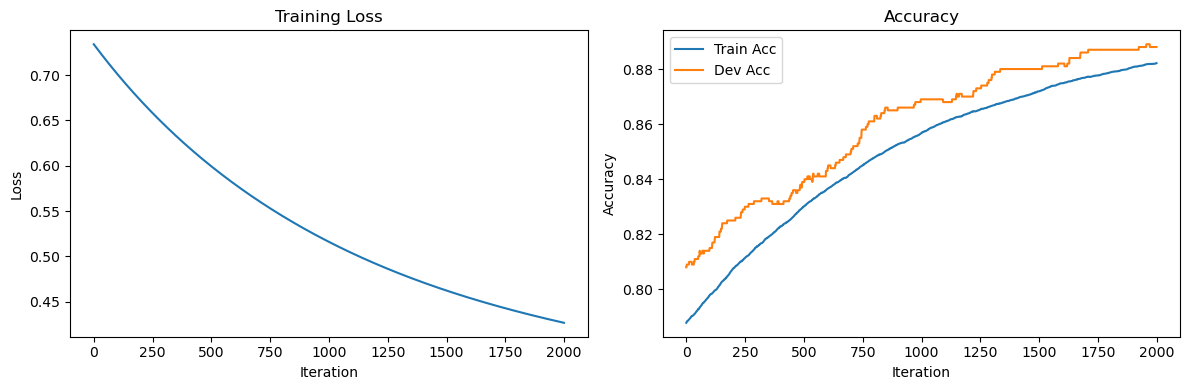

In [87]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(dev_accs, label="Dev Acc")
plt.title("Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [94]:
def show_samples(X, y_true, y_pred, n=9):
    idxs = np.random.choice(X.shape[1], n, replace=False)

    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        img = X[:, idx].reshape(28, 28)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"P: {y_pred[idx]} | T: {y_true[idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

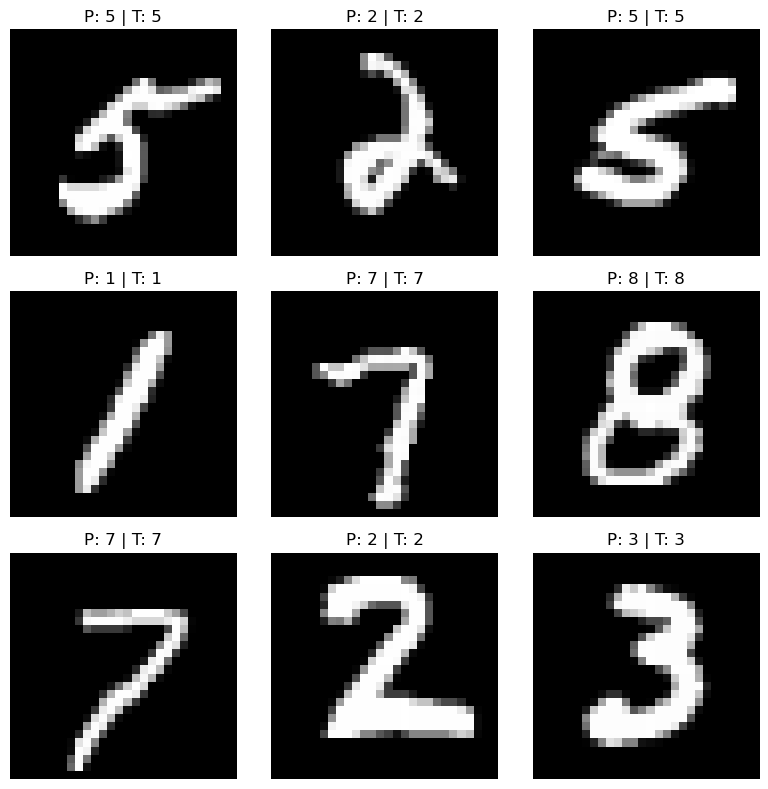

In [102]:
show_samples(X_test, y_test, output_labels, n=9)

In [103]:
def show_wrong_samples(X, y_true, y_pred, n=9):
    wrong_idx = np.where(y_pred != y_true)[0]

    if len(wrong_idx) == 0:
        print("Không có mẫu đoán sai.")
        return

    n = min(n, len(wrong_idx))
    idxs = np.random.choice(wrong_idx, n, replace=False)

    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        img = X[:, idx].reshape(28, 28)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"P: {y_pred[idx]} | T: {y_true[idx]}", color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

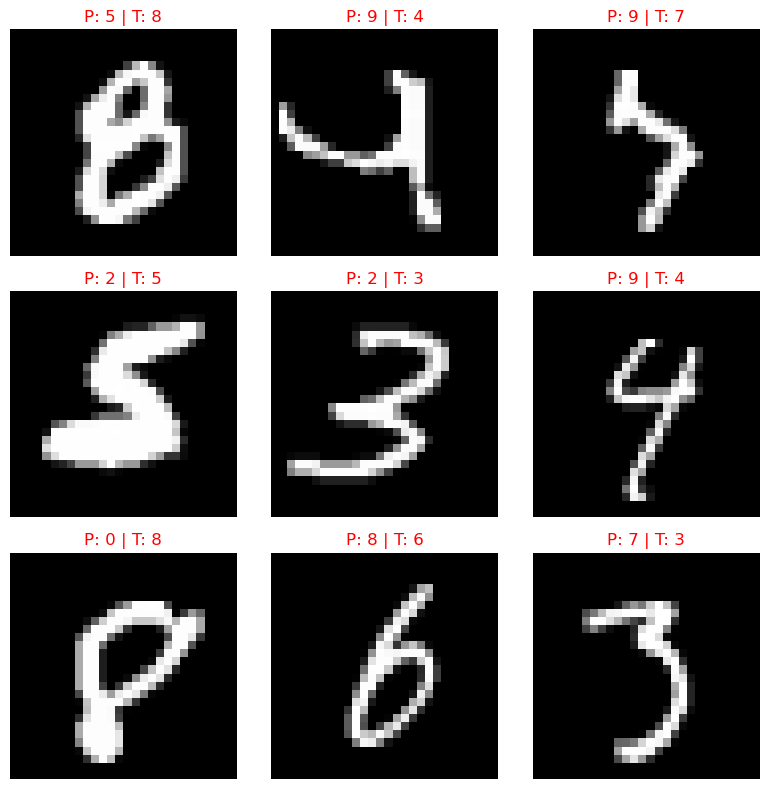

In [105]:
show_wrong_samples(X_test, y_test, output_labels, n=9)